In [1]:
from datetime import date
from pathlib import Path

from tapas_gmm.env.rlbench import RLBenchEnvironment, RLBenchEnvironmentConfig
from tapas_gmm.policy.gmm import GMMPolicy, GMMPolicyConfig
from tapas_gmm.policy.models.tpgmm import AutoTPGMMConfig
from tapas_gmm.viz.gmm import plot_gmm_components

from rlbench.action_modes.arm_action_modes import BimanualEndEffectorPoseViaIK

import imageio.v2 as imageio
import matplotlib.pyplot as plt

2026-07-28 21:23:22.098 | INFO     |  Running on cpu


/home/nils/Documents/Study Project/Code/riepybdlib/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
checkpoint_root = Path("../artifacts/checkpoints/tapas")
checkpoint_dir = max(path for path in checkpoint_root.iterdir() if path.is_dir())
model_path = checkpoint_dir / "latest.pkl"
video_dir = Path("../artifacts/videos/tapas") / date.today().isoformat()
video_dir.mkdir(parents=True, exist_ok=True)

In [3]:
tapas_env = RLBenchEnvironment(
    RLBenchEnvironmentConfig(
        action_mode = BimanualEndEffectorPoseViaIK,
        robot_setup = "dual_panda",
        task = "BimanualDualPushButtons",
        cameras = ("front",),
        camera_pose = {},
        image_size = (128, 128),
        static = False,
        headless = False,
        scale_action = False,
        delay_gripper = False,
        gripper_plot = False,   
    )
)

policy = GMMPolicy(
    GMMPolicyConfig(
        suffix=None,
        model = AutoTPGMMConfig(),
        batch_predict_in_t_models = False,
        topp_in_t_models = False,
        dbg_prediction = True,
        binary_gripper_action = True,
        force_overwrite_checkpoint_config = True,
        pos_lag_thresh=0.03,
        quat_change_thresh=0.1,
    )
)

2026-07-28 21:23:57.181 | INFO     |  Initializing Policy:
2026-07-28 21:23:57.182 | INFO     |  No encoder config provided. Using None.
None


2026-07-28 21:23:59.030 | INFO     |  Loading model:
2026-07-28 21:23:59.197 | ERROR    |  Config mismatch
root.tpgmm.n_components 10 != 4
root.tpgmm.reg_em_finish_diag_gripper 0.02 != 0.1
root.tpgmm.reg_em_trans 1e-06 != None
root.tpgmm.add_time_component True != False
root.tpgmm.reg_em_finish_diag 0.0002 != 0.001
root.tpgmm.reg_init_diag 0.0005 != 5e-05
root.tpgmm.reg_diag  0.0002 != 0.001
root.tpgmm.add_action_component False != True
root.tpgmm.add_gripper_action True != False
root.tpgmm.reg_diag_gripper 0.02 != 0.1
root.frame_selection.rel_score_threshold 0.1 != 0.75
root.demos_segmentation.min_n_components 3 != 1
root.demos_segmentation.velocity_based True != False
root.demos_segmentation.components_prop_to_len True != False
root.demos_segmentation.distance_based False != True

2026-07-28 21:23:59.197 | WARNING  |  Overwriting config. This can lead to unexpected errors.
2026-07-28 21:23:59.197 | INFO     |  Detected time-based model: True. Using time-driven policy. Set time_based 

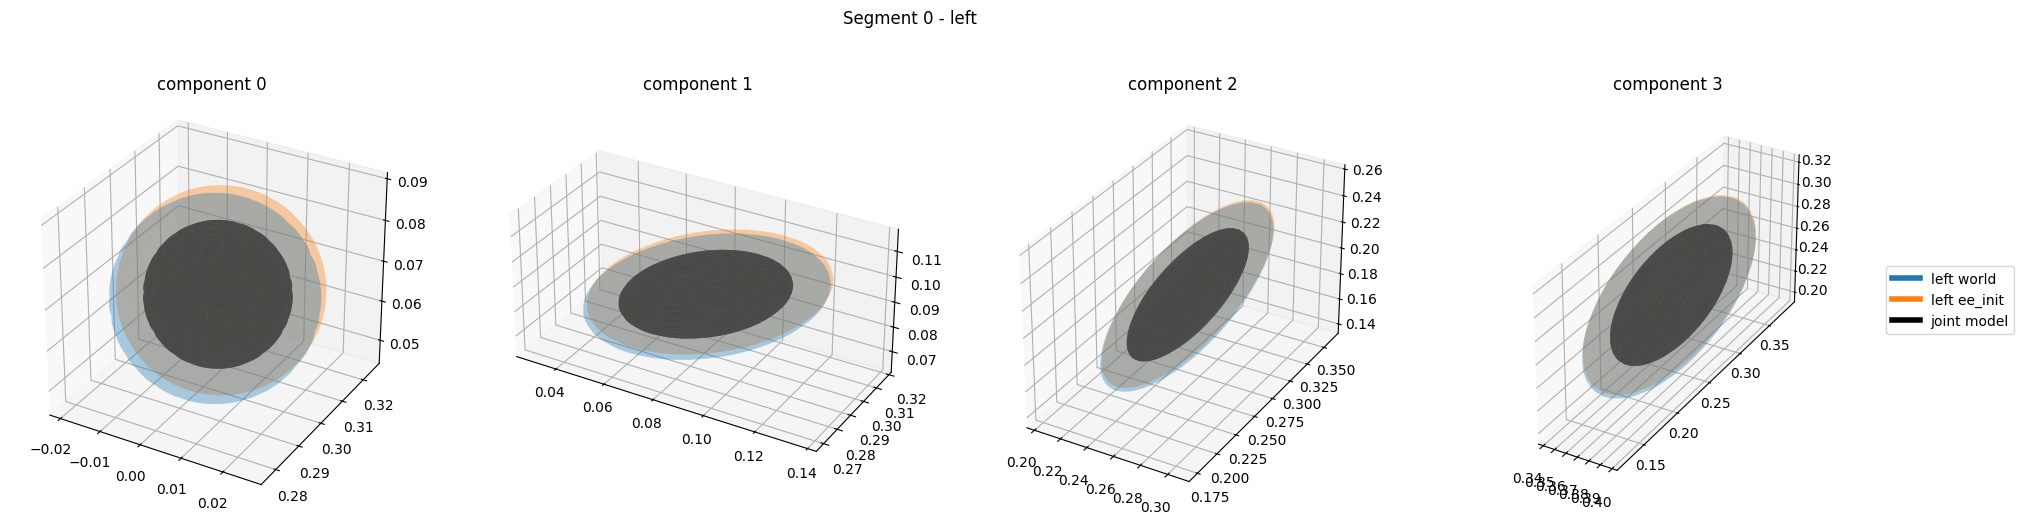

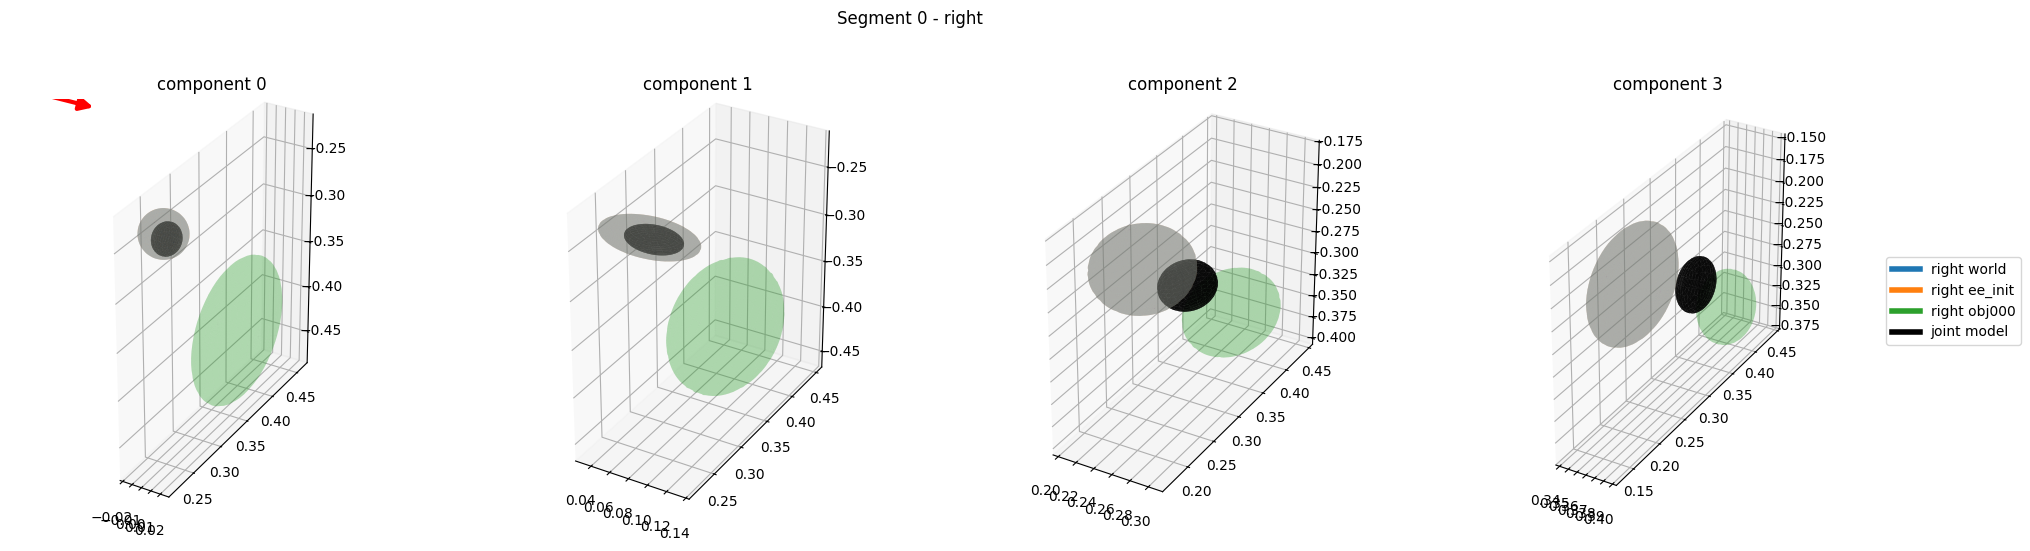

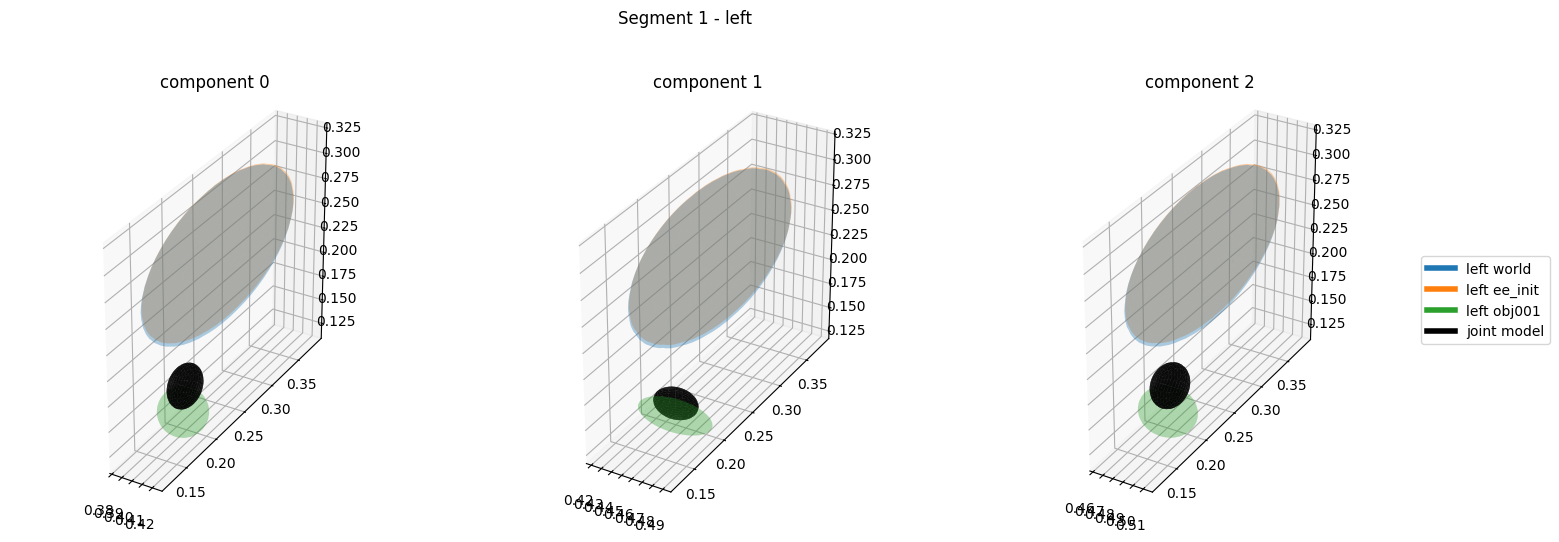

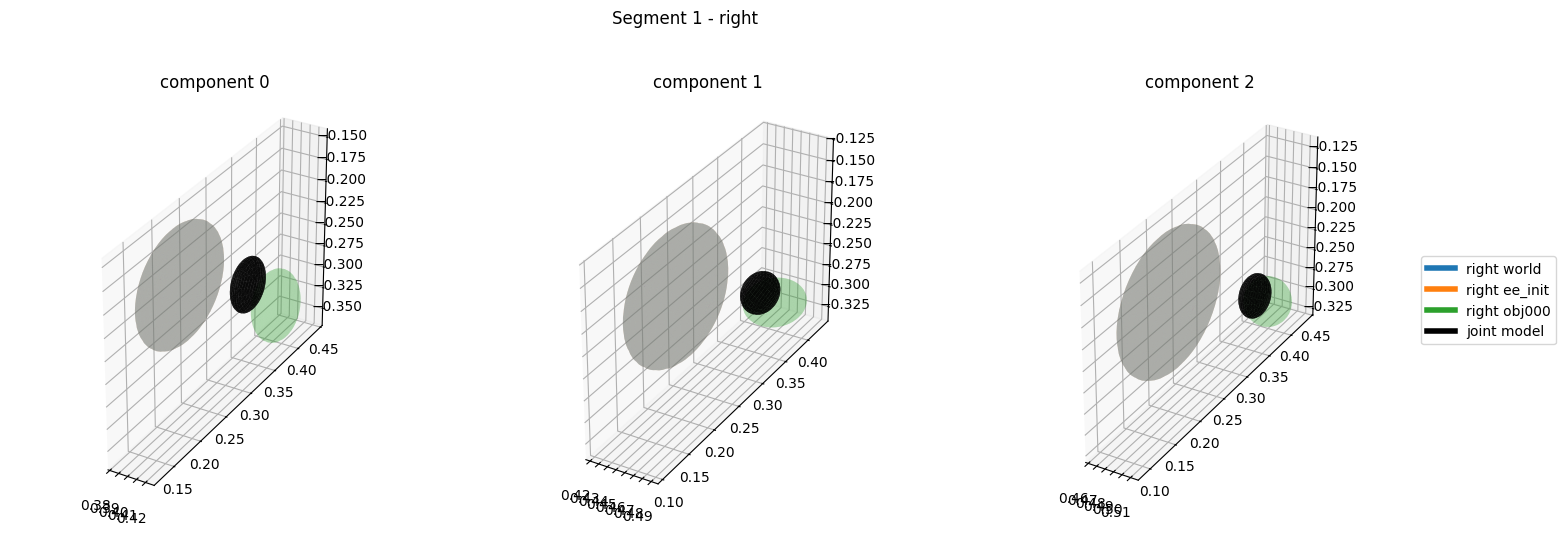

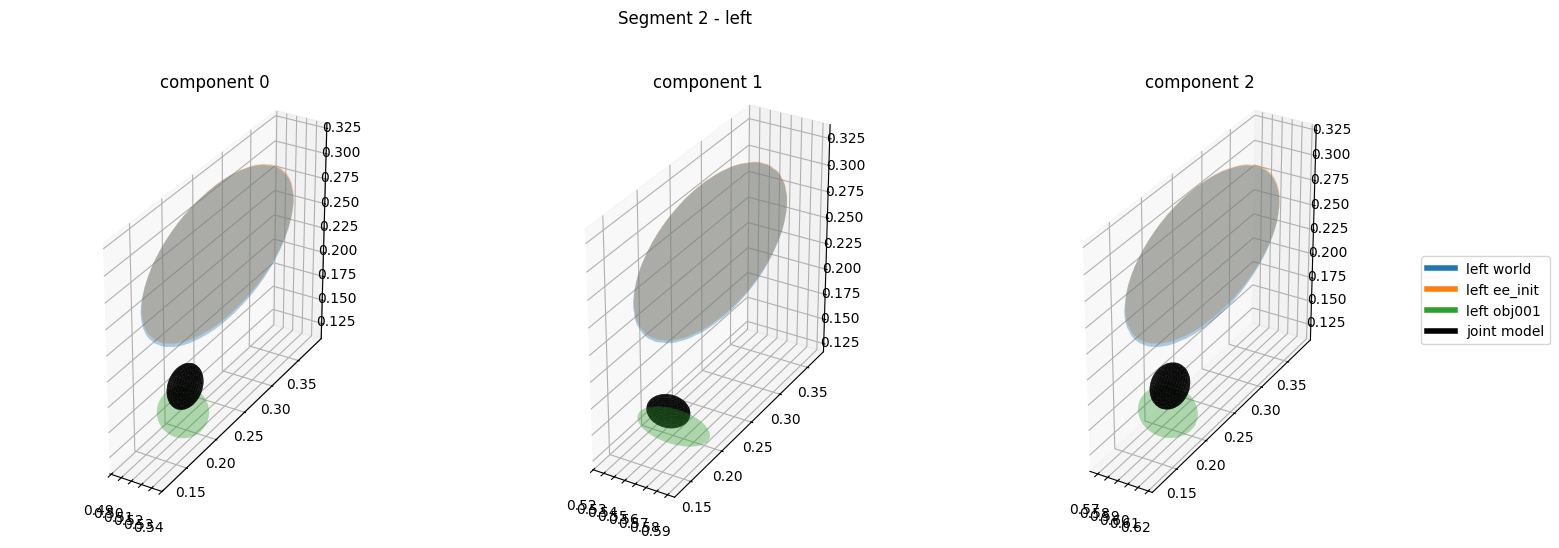

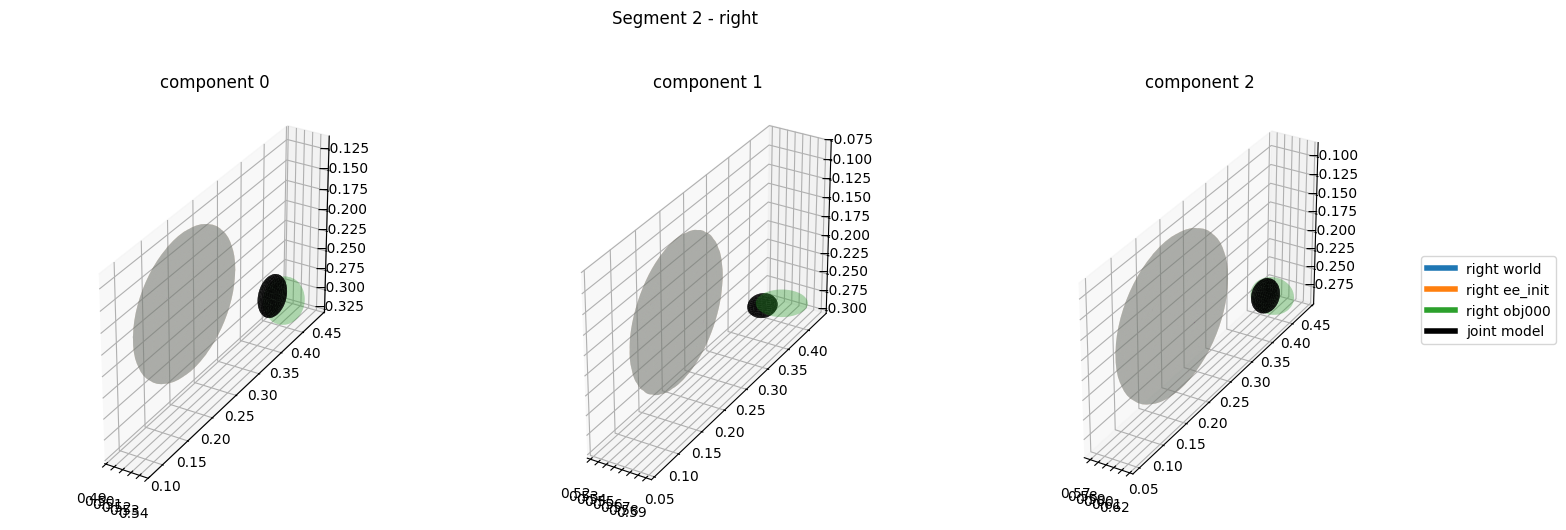

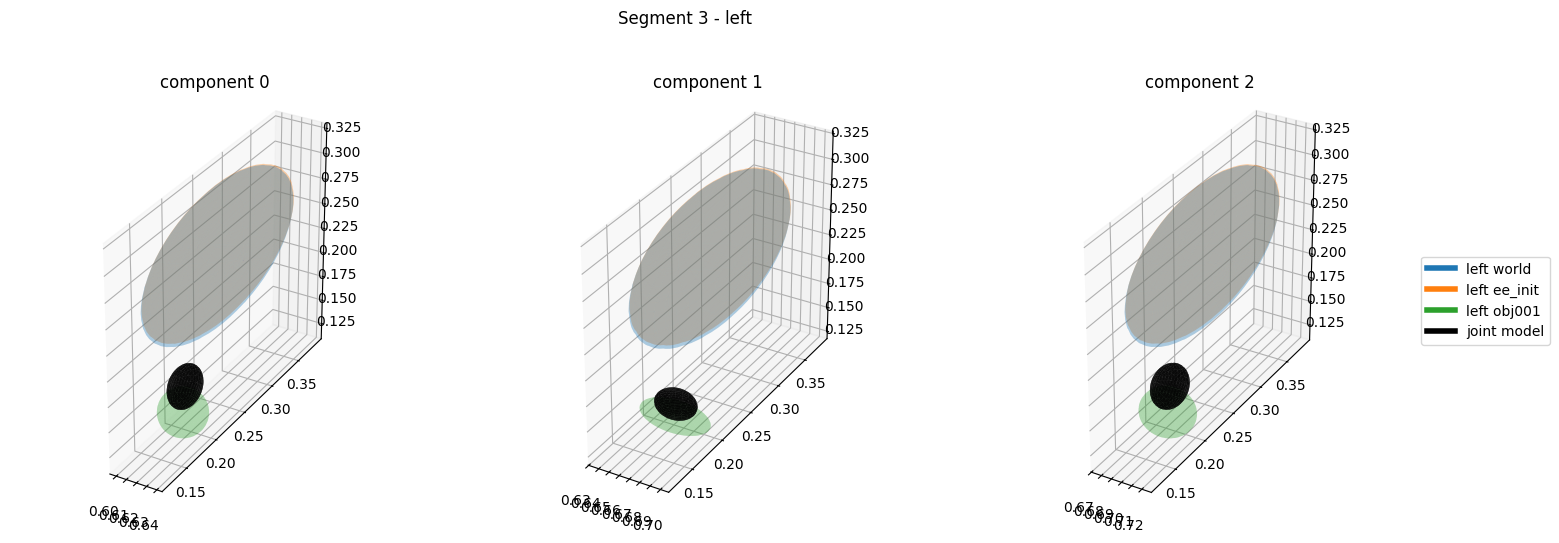

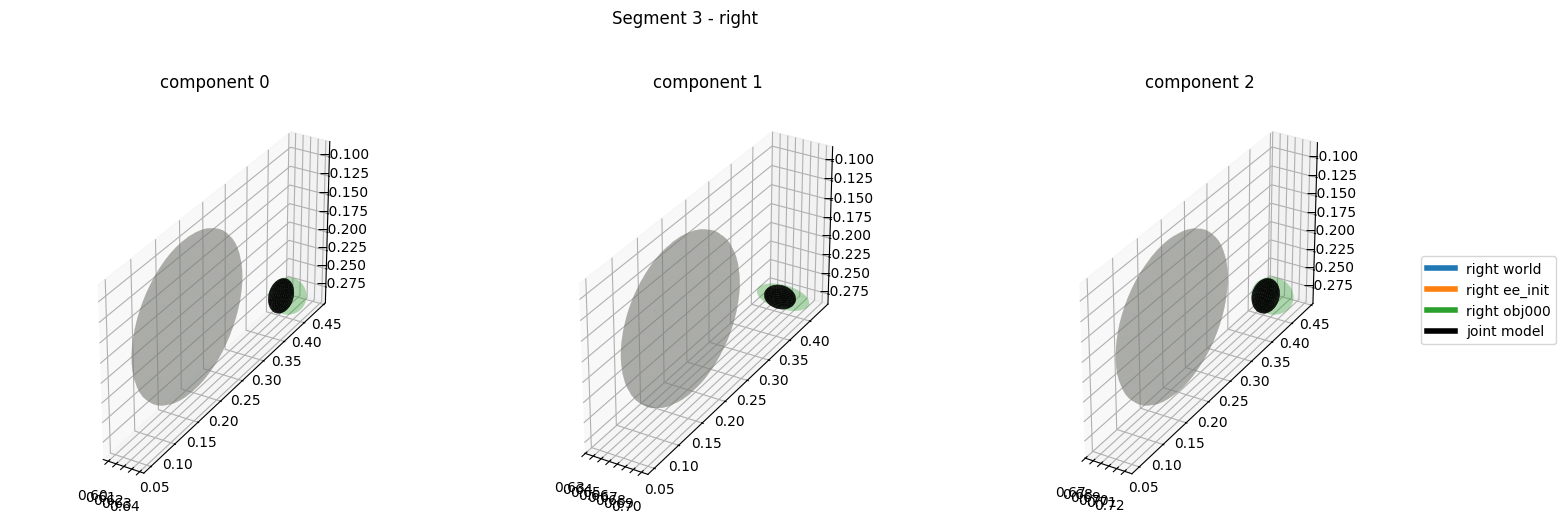

In [4]:
obs = tapas_env.reset()
policy.from_disk(str(model_path))
policy.eval()
policy.reset_episode(tapas_env)

if policy.config.dbg_prediction:
    frame_trans, frame_quats = policy.get_frames(obs)
    joint_models, trans_marginals = policy.model._make_segment_joint_models(
        frame_trans,
        frame_quats,
        policy._local_marginals,
        heal_time_variance=False,
    )

    for segment, segment_gmm in enumerate(policy.model.segment_gmms):
        frame_data = policy.model.segment_frame_views[segment]
        n_left = len(frame_data.left_frame_indecies or [])

        plot_gmm_components(
            segment_gmm.model,
            (joint_models[segment][0],),
            (trans_marginals[segment][0],),
            frame_data.frame_names[:n_left],
        )
        plt.suptitle(f"Segment {segment} - left")
        plt.show()

        plot_gmm_components(
            segment_gmm.model,
            (joint_models[segment][1],),
            (trans_marginals[segment][1],),
            frame_data.frame_names[n_left:],
        )
        plt.suptitle(f"Segment {segment} - right")
        plt.show()

In [5]:
total_reward = 0
frames = []

for step in range(450):
    action, info = policy.predict(obs)
    obs, reward, done, env_info = tapas_env.step(action)
    frame = obs.cameras["front"].rgb

    if frame.ndim == 4:
        frame = frame[0]

    if frame.shape[0] == 3:
        frame = frame.permute(1, 2, 0)

    frame = (frame * 255).clip(0, 255).byte().cpu().numpy()
    frames.append(frame)
    total_reward += reward

    if obs is None or done or info.get("done", False):
        break

imageio.mimsave(video_dir / "run.mp4", frames, fps=20, format="FFMPEG")

print("steps:", step + 1)
print("total_reward:", total_reward)

tapas_env.close()

2026-07-28 21:24:08.868 | INFO     |  Action [-1.52609243e-03  4.56947424e-03 -1.61804931e-02 -1.61923155e-02
  7.62951105e-04 -1.28500768e-01  9.91576916e-01  1.00000000e+00
  0.00000000e+00 -9.12132746e-03 -9.11033052e-03 -2.29206705e-02
  7.80046048e-04  1.36722171e-02  4.40558889e-03  9.99896521e-01
  1.00000000e+00  0.00000000e+00]
2026-07-28 21:24:08.874 | INFO     |  Skipping invalid action [-1.52609243e-03  4.56947424e-03 -1.61804931e-02 -1.61923155e-02
  7.62951105e-04 -1.28500768e-01  9.91576916e-01  1.00000000e+00
  0.00000000e+00 -9.12132746e-03 -9.11033052e-03 -2.29206705e-02
  7.80046048e-04  1.36722171e-02  4.40558889e-03  9.99896521e-01
  1.00000000e+00  0.00000000e+00].


2026-07-28 21:24:10.718 | INFO     |  Pos lag: [[-0.00390409  0.00879569 -0.02484954]
 [-0.00257417  0.00456417 -0.0164395 ]], quat lag: 0.5195444584455755, pos change [[-2.4509430e-04 -1.4171004e-05  4.1139126e-04]
 [ 1.7206371e-04  5.4538250e-06  3.6573410e-04]], quat change 0.001953125019402554
2026-07-28 21:24:10.719 | INFO     |  Action [-1.43339497e-03  4.56391937e-03 -1.65780290e-02 -1.61435782e-02
  3.61484899e-04 -1.28511000e-01  9.91576612e-01  1.00000000e+00
  0.00000000e+00 -8.96201522e-03 -9.10328679e-03 -2.33862794e-02
  7.73951642e-04  1.32539922e-02  4.40564202e-03  9.99902157e-01
  1.00000000e+00  0.00000000e+00]
2026-07-28 21:24:10.722 | INFO     |  Skipping invalid action [-1.43339497e-03  4.56391937e-03 -1.65780290e-02 -1.61435782e-02
  3.61484899e-04 -1.28511000e-01  9.91576612e-01  1.00000000e+00
  0.00000000e+00 -8.96201522e-03 -9.10328679e-03 -2.33862794e-02
  7.73951642e-04  1.32539922e-02  4.40564202e-03  9.99902157e-01
  1.00000000e+00  0.00000000e+00].
2026-

/home/nils/Documents/Study Project/Code/TAPAS/tapas_gmm/utils/geometry_np.py:84: RuntimeWarning: invalid value encountered in arccos
  theta = 2 * np.arccos(2 * np.dot(q, r) ** 2 - 1)


2026-07-28 21:24:11.771 | INFO     |  Action [ 2.70746949e-03 -1.12426462e-03  1.22907370e-02  1.71994959e-04
 -5.84293897e-04 -6.15824897e-05  9.99999813e-01  1.00000000e+00
  0.00000000e+00  5.88814219e-03  6.10028499e-03  1.71288213e-02
 -3.47929129e-06 -2.03638402e-04  1.35314254e-05  9.99999979e-01
  1.00000000e+00  0.00000000e+00]
2026-07-28 21:24:11.978 | INFO     |  Pos lag: [[ 3.26341637e-04 -2.09933177e-04  2.18893145e-04]
 [-2.44700122e-04 -5.43802374e-05 -1.09595420e-04]], quat lag: 0.003152431185987311, pos change [[ 0.00226095 -0.00571385  0.01776707]
 [ 0.00085703 -0.00132942  0.01265419]], quat change 0.0
2026-07-28 21:24:11.979 | INFO     |  Action [ 2.17922846e-04  6.66443444e-06 -1.65262616e-04  2.03027654e-04
 -7.07526911e-04 -1.91080120e-05  9.99999729e-01  1.00000000e+00
  0.00000000e+00  3.48230558e-04  2.34751862e-04  1.48701230e-04
 -2.22064051e-05 -6.67634579e-04  1.89844107e-05  9.99999777e-01
  1.00000000e+00  0.00000000e+00]
2026-07-28 21:24:12.062 | INFO  

In [6]:
tapas_env.close()